In [1]:
import torch
import torch.nn as nn 
from torch.func import jacrev
from torch.func import vmap

import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp

plt.rcParams["figure.figsize"] = (10, 8)

device = 'cuda'

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
'''
 concept: 
    1. we have a unicycle with CONSTANT input and FIXED time interval for the simulation
    2. define dataset as [t, g=(x, y, theta)]
    3. train std pinn 

    state: [x, y, theta]
    input: [v, w] --> const
 '''
' '

' '

In [5]:
# Piecewise constant control using expanded commands
# used for save and generate the constant command over the interval 

class ExpandedControl:
    def __init__(self, expanded_time, expanded_commands):
        self.expanded_time = expanded_time
        self.expanded_commands = expanded_commands

    def __call__(self, t):
        idx = np.searchsorted(self.expanded_time, t, side='right') - 1
        idx = np.clip(idx, 0, len(self.expanded_commands) - 1)
        return self.expanded_commands[idx]

In [45]:
#@ pinn Dataset  (NOT pinn-C) --> constant control over entire trajectory
# # first test: unicycle kinematics with constant input 
def control_input():

    return np.array([1, 0.1])

def kin_unicycle(t, x):

    u = control_input()
    dx = np.zeros(3)
    dx[0] = np.cos(x[2])*u[0]
    dx[1] = np.sin(x[2])*u[0]
    dx[2] = u[1]
    return dx


time_range = [0.0, 20.0]
time_eval = np.linspace(time_range[0], time_range[1], 1000)

init_condition_X = np.array([0, 0, 0])

# not used for now
init_condition_U = np.array([1, 0.1]) 

unikin_integration = solve_ivp(
    kin_unicycle,
    time_range,
    init_condition_X, 
    t_eval=time_eval)

In [115]:
#@ Pinn-C dataset (with control input)

time_range = [0.0, 20.0]
time_points = np.linspace(time_range[0], time_range[1], 1000)

commands = np.zeros((len(time_points), 2))
# smooth input 
commands[:, 0] = 0.2 # 0.5* np.random.rand(time_points.shape[0])
commands[:, 1] = 0.1 * np.sin(0.5 * time_points) #- np.cos(0.1 * time_points)


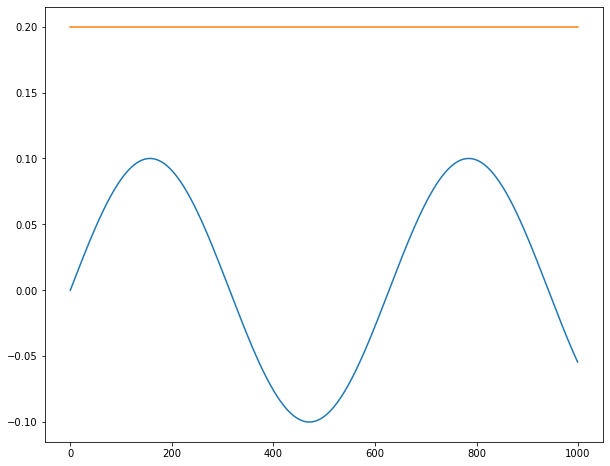

In [116]:
plt.plot(commands[:, 1])
plt.plot(commands[:, 0])

In [117]:

# downsample the commands: constant for each 5 timestep
# 1 timestep = 20.0 sec / 1000 time_step = 0.02 sec


delta_t = 5
T_max = delta_t * 0.02 
for i in range(0, len(time_points), delta_t):
    commands[i:i+delta_t, 0] = commands[i, 0]
    commands[i:i+delta_t, 1] = commands[i, 1]

control = ExpandedControl(time_points, expanded_commands=commands)


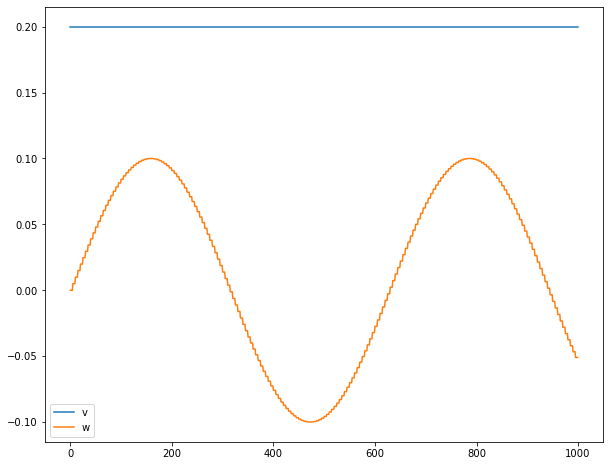

In [118]:
plt.plot(control(time_points)[:, 0], label='v')
plt.plot(control(time_points)[:, 1], label='w')
plt.legend()

In [99]:
# Kinematic model of the unicycle
def kin_unicycle(t, x, control_input):
    u = control(t)  # Get the control input at time `t`
    dx = np.zeros(3)
    dx[0] = np.cos(x[2]) * u[0]
    dx[1] = np.sin(x[2]) * u[0]
    dx[2] = u[1]
    return dx

# Integration parameters
init_condition_X = np.array([0, 0, 0])

# Solve the unicycle model
unikin_integration = solve_ivp(
    lambda t, x: kin_unicycle(t, x, control),
    time_range,
    init_condition_X,
    t_eval=time_points,
)


# Access results
t_values = unikin_integration.t
trajectory = unikin_integration.y



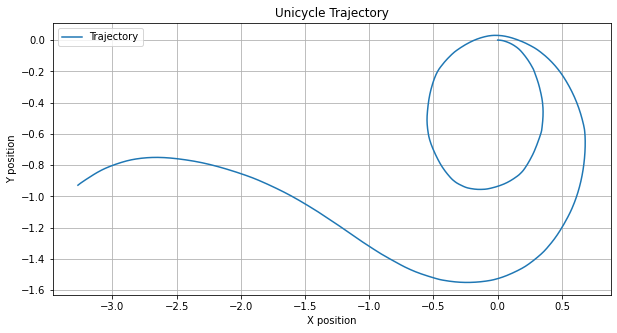

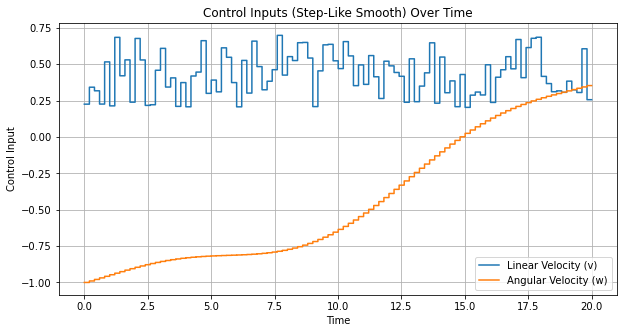

In [100]:
#@ Plot results
# Plot trajectory
plt.figure(figsize=(10, 5))
plt.plot(trajectory[0], trajectory[1], label="Trajectory")
plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("Unicycle Trajectory")
plt.legend()
plt.grid()

# Plot control inputs over time
plt.figure(figsize=(10, 5))
plt.step(t_values, commands[:, 0], label="Linear Velocity (v)", where='post')
plt.step(t_values, commands[:, 1], label="Angular Velocity (w)", where='post')
plt.xlabel("Time")
plt.ylabel("Control Input")
plt.title("Control Inputs (Step-Like Smooth) Over Time")
plt.legend()
plt.grid()

plt.show()


In [101]:
#@ NON-SAMPLED DATA
# this cell generate a full trajectory [except the last N point saved for eval]

X_dataset = []
Y_dataset = []
for i in range(0, trajectory.shape[1]-(200), delta_t): # step di 5

    # input
    T = np.linspace(0, T_max, delta_t).reshape(-1, 1)
    x_0 = trajectory[:, i, np.newaxis]
    x_0 = x_0.repeat(delta_t, axis=1).T  # 3x5 --> (x, y, 0) for 5 time step
    const_commands = commands[i:i+delta_t, :]

    X = np.hstack([x_0, const_commands, T])
    X_dataset.append(X)

    # output
    Y = trajectory[:, i:i+delta_t].T
    Y_dataset.append(Y)

X_train = np.concatenate(X_dataset)
Y_train = np.concatenate(Y_dataset)


In [102]:
# eval dataset
X_dataset = []
Y_dataset = []
for i in range(0, trajectory.shape[1], delta_t): # step di 5

    T = np.array([T_max]).reshape(1, -1)
    x_0 = trajectory[:, i, np.newaxis]
    const_commands = commands[i, :].reshape(1, -1).T
    X = np.vstack([
        x_0,
        const_commands,
        T])

    X_dataset.append(X)
    Y_dataset.append(trajectory[:, i].T)

X_eval = np.hstack(X_dataset).T
Y_eval = np.stack(Y_dataset)

In [120]:
X_eval[:, -1]

tensor([0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 

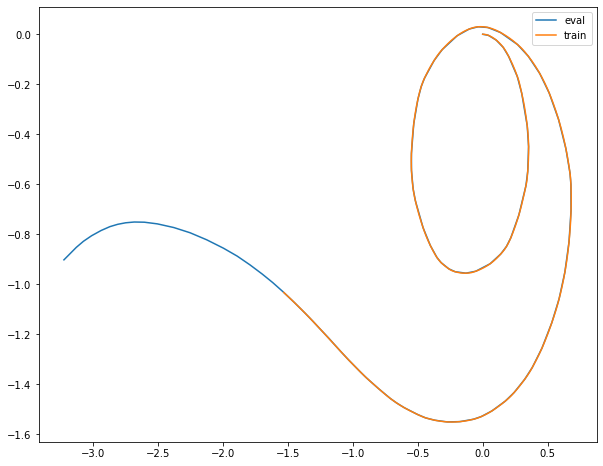

In [58]:
plt.plot(Y_eval[:, 0], Y_eval[:, 1], label='eval')
plt.plot(Y_train[:, 0], Y_train[:, 1], label='train')
plt.legend()

In [103]:
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
Y_train = torch.tensor(Y_train, dtype=torch.float32, device=device)
X_eval = torch.tensor(X_eval, dtype=torch.float32, device=device)
Y_eval = torch.tensor(Y_eval, dtype=torch.float32, device=device)

In [104]:

t_max, t_min = torch.tensor([T_max], device=device), torch.tensor([0.0], device=device)
x_max, x_min = Y_eval.max(0)[0][0].to(device), Y_eval.min(0)[0][0].to(device) 
y_max, y_min = Y_eval.max(0)[0][1].to(device), Y_eval.min(0)[0][1].to(device)
theta_max, theta_min = Y_eval.max(0)[0][2].to(device), Y_eval.min(0)[0][2].to(device)

In [105]:
u_max, u_min = commands.max(0)[0], commands.min(0)[0]
w_max, w_min = commands.max(0)[1], commands.min(0)[1]

In [106]:
pinn_c = nn.Sequential(
    nn.Linear(6, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 3)
).to(device)

pinn_c_opti = torch.optim.Adam(pinn_c.parameters(), lr=1e-3)
loss_mse = nn.MSELoss()
epoch_counter = 0

In [121]:
for i in range(10_000):

    epoch_counter += 1
    pinn_c_opti.zero_grad()

    pred = pinn_c(X_train)

    # loss by imit datapoint
    loss_imit = loss_mse(pred, Y_train)

    # loss by pinn
    N_sample = 2_000
    # random time in range(0, 0.01)
    sampled_t = torch.rand(N_sample, 1).to(device) * (t_max - t_min) + t_min
    
    # random sample
    sampled_x = torch.rand(N_sample, 1).to(device) * (x_max - x_min) + x_min
    sampled_y = torch.rand(N_sample, 1).to(device) * (y_max - y_min) + y_min
    sampled_theta = torch.rand(N_sample, 1).to(device) * (theta_max - theta_min) + theta_min

    # random input
    sampled_u = torch.randn(N_sample, 1).to(device) * (u_max - u_min) + u_min
    sampled_w = torch.randn(N_sample, 1).to(device) * (w_max - w_min) + w_min

    # concat the random componet
    sample = torch.concatenate([
        sampled_x, sampled_y, sampled_theta, 
        sampled_u, sampled_w, 
        sampled_t
    ], -1).to(device)
    sample.requires_grad = True

    # physical system prediction

    pred_output = pinn_c(sample)
    # calc jacobian respect the output of the net
    d_output = vmap(jacrev(pinn_c))(sample).squeeze()
    # extract derivative respect time --> dx_dt, dy_dt, dtheta_dt
    d_output = d_output[:, :, -1]


    # compute the ode of the kin model
    pred_dx = torch.cos(pred_output[:, 2]) * control_input()[0]
    pred_dy = torch.sin(pred_output[:, 2]) * control_input()[0]
    pred_dtheta = (control_input()[1] * torch.ones(pred_dy.shape[0])).to(device)

    physics_val = torch.vstack([pred_dx, pred_dy, pred_dtheta]).T

    # compute the cost 
    F_cost = torch.mean(torch.mean((physics_val - d_output)**2, axis=1))


    # boundary condition: No input AKA no velocity

    # no velocity ---> no motion:
    # opt 1: apply this at gradient level:
    
    # dx = 0 * cos(*) = 0
    # dy = 0 * sin(*) = 0
    # dtheta = 0

    # opt 2 : apply this at prediciton level:
    # given x --> f(x) = x (no motion)


    loss = loss_imit + F_cost
    

    loss.backward()
    pinn_c_opti.step()

    if i % 100 == 0:
        print(f'iter: {epoch_counter} Loss: {loss.item()}, loss_imit: {loss_imit.item()}, F_cost: {F_cost.item()}')
        

iter: 30001 Loss: 0.0004371638351585716, loss_imit: 0.0003955820866394788, F_cost: 4.158175943302922e-05
iter: 30101 Loss: 0.00039477660902775824, loss_imit: 0.00036154050030745566, F_cost: 3.3236105082323775e-05
iter: 30201 Loss: 0.00037385194445960224, loss_imit: 0.00035049146390520036, F_cost: 2.336048783035949e-05
iter: 30301 Loss: 0.00037961892667226493, loss_imit: 0.0003562829806469381, F_cost: 2.3335949663305655e-05
iter: 30401 Loss: 0.00037663799594156444, loss_imit: 0.0003513772098813206, F_cost: 2.526077332731802e-05
iter: 30501 Loss: 0.00040551149868406355, loss_imit: 0.0003658473724499345, F_cost: 3.966412987210788e-05
iter: 30601 Loss: 0.00038317061262205243, loss_imit: 0.0003585327649489045, F_cost: 2.4637853130116127e-05
iter: 30701 Loss: 0.00040791681385599077, loss_imit: 0.0003740336396731436, F_cost: 3.3883185096783563e-05
iter: 30801 Loss: 0.00040968068060465157, loss_imit: 0.00037338267429731786, F_cost: 3.6297995393397287e-05
iter: 30901 Loss: 0.0004164375714026391

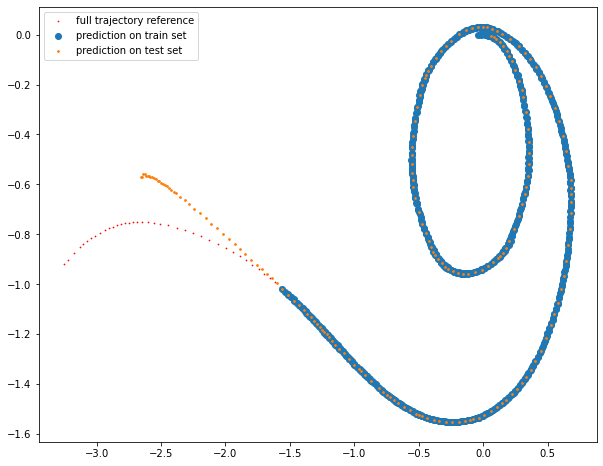

In [122]:
pred_full_traj = pinn_c(X_eval).detach().cpu().numpy().T
pred = pinn_c(X_train).detach().cpu().numpy().T
#plt.scatter(Y_train[0], Y_train[1], label='data points train')
plt.scatter(Y_eval.detach().cpu().numpy()[:, 0], Y_eval.detach().cpu().numpy()[:, 1], c='r', s=0.5, label='full trajectory reference')
plt.scatter(pred[0], pred[1], label='prediction on train set')
plt.scatter(pred_full_traj[0], pred_full_traj[1], label='prediction on test set', s=3)

plt.legend()


In [123]:
torch.save(pinn_c.state_dict(), 'pinn_c.pth')